# Polarity and Distribution Tutorial

This notebook shows how to:
- plot grouped distributions
- control axis limits and visual style
- further customize the returned figure object
- save vector graphics explicitly (SVG/PDF/EPS)


In [1]:
import numpy as np
import pandas as pd

from CCSNE.illustration import (
    plot_distribution_by_category,
    plot_phase_rose,
    plot_polarity_violin,
    plot_rayleigh_by_polarity,
    save_matplotlib_figure,
    save_plotly_figure,
)


In [2]:
rng = np.random.default_rng(42)

res = pd.DataFrame({
    "polarity": ["Positive"] * 80 + ["Negative"] * 80 + ["combined"] * 80,
    "rayleigh_stat": np.concatenate([
        rng.gamma(2.4, 1.2, 80),
        rng.gamma(2.0, 1.1, 80),
        rng.gamma(1.8, 1.0, 80),
    ]),
})
res["rayleigh_p"] = np.exp(-res["rayleigh_stat"])
res.head()


,polarity,rayleigh_stat,rayleigh_p
0,Positive,3.043686,0.047659
1,Positive,4.012947,0.018080
2,Positive,2.707140,0.066727
3,Positive,2.451129,0.086196
4,Positive,4.327419,0.013202


In [3]:
# Style and axis range directly via function parameters.
fig = plot_rayleigh_by_polarity(
    res,
    y_range=(0, 12),
    font_size=18,
    tick_font_size=14,
    axis_line_width=2.5,
    tick_width=2.5,
    tick_len=10,
)
fig.show()


In [4]:
fig2 = plot_distribution_by_category(
    df=res.rename(columns={"polarity": "group", "rayleigh_stat": "metric"}),
    value_col="metric",
    category_col="group",
    colormap="viridis",
    show_annotations=True,
)
fig2.update_yaxes(range=(0, 12))
fig2.update_layout(title="Manual post-edit on returned figure", width=820, height=540)
fig2.show()


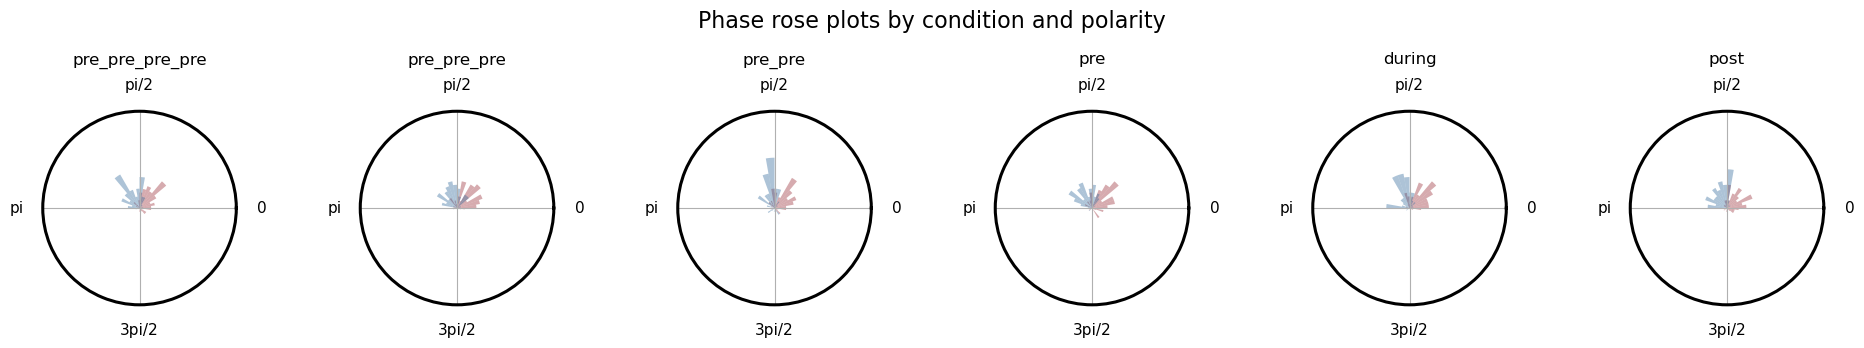

In [6]:
fig4, axes = plot_phase_rose(
    df=df,
    phase_col="phase",
    conditions=conditions,
    radial_limit=(0, 25),
    font_size=16,
    tick_font_size=11,
    axis_line_width=2.2,
    tick_width=2.0,
    tick_len=8,
)


In [ ]:
# Saving is explicit and optional. No figure is saved unless you call these.
# Requires `kaleido` for Plotly static export.
# pip install kaleido

save_plotly_figure(fig3, "outputs/polarity_violin.svg")
save_plotly_figure(fig3, "outputs/polarity_violin.pdf")
save_matplotlib_figure(fig4, "outputs/phase_rose.eps")
